In [1]:
import heapq

graph = {
    'A': [('B',4), ('C',1)],
    'B': [('D',2)],
    'C': [('B',2), ('D',5)],
    'D': []
}

def dijkstra(graph, start):
    pq = [(0, start)]
    distances = {node: float('inf') for node in graph}
    distances[start] = 0

    while pq:
        current_distance, current_node = heapq.heappop(pq)

        for neighbor, weight in graph[current_node]:
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                heapq.heappush(pq, (distance, neighbor))

    return distances

print(dijkstra(graph,'A'))

{'A': 0, 'B': 3, 'C': 1, 'D': 5}


{'A': [('B', 4), ('C', 1)], 'B': [('D', 2)], 'C': [('B', 2), ('D', 5)], 'D': []}


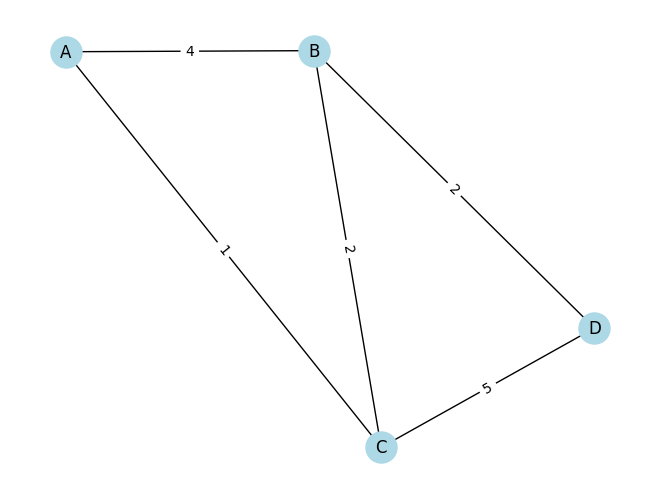

In [3]:
# print the graph
print(graph)
# visualize the graph
import matplotlib.pyplot as plt
import networkx as nx
G = nx.Graph()
for node, edges in graph.items():
    for neighbor, weight in edges:
        G.add_edge(node, neighbor, weight=weight)
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()


Shortest Distance: 20
Shortest Path: Q -> B -> D -> F -> M


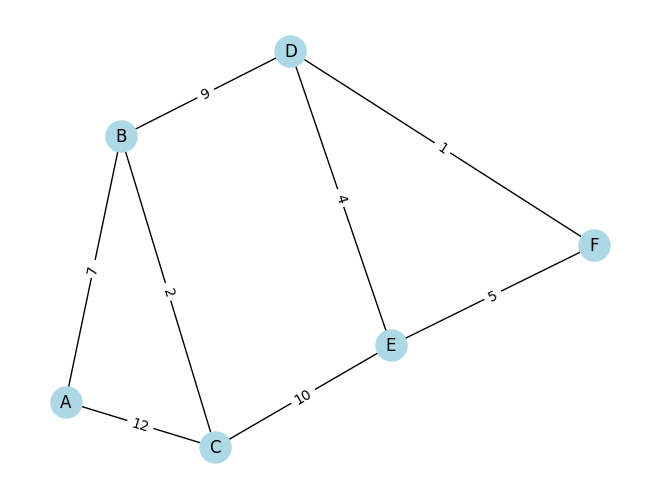

In [ ]:
# the graph visualization 
import matplotlib.pyplot as plt
import networkx as nx
G = nx.Graph()
for node, edges in graph.items():
    for neighbor, weight in edges:
        G.add_edge(node, neighbor, weight=weight)
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()


In [10]:
import heapq

# Graph representation (Adjacency List)
graph = {
    'Q': [('A',7), ('I',12)],
    'A': [('I',2), ('S',9)],
    'I': [('R',10)],
    'S': [('M',1)],
    'R': [('S',4), ('M',5)],
    'M': []
}

def dijkstra(graph, start, target):

    # Distance of every node from start
    distances = {node: float('inf') for node in graph}
    distances[start] = 0

    # To store previous node for path reconstruction
    previous = {node: None for node in graph}

    # Priority queue
    pq = [(0, start)]

    while pq:

        current_distance, current_node = heapq.heappop(pq)

        # Stop if we reached target
        if current_node == target:
            break

        for neighbor, weight in graph[current_node]:

            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(pq, (distance, neighbor))

    # Reconstruct shortest path
    path = []
    node = target

    while node is not None:
        path.append(node)
        node = previous[node]

    path.reverse()

    return distances, path


distances, path = dijkstra(graph, 'Q', 'M')

print("Shortest distance from Q to M:", distances['M'])
print("Shortest path:", " -> ".join(path))

print("\nDistance to each node:")
for node, dist in distances.items():
    print(node, ":", dist)

Shortest distance from Q to M: 17
Shortest path: Q -> A -> S -> M

Distance to each node:
Q : 0
A : 7
I : 9
S : 16
R : 19
M : 17


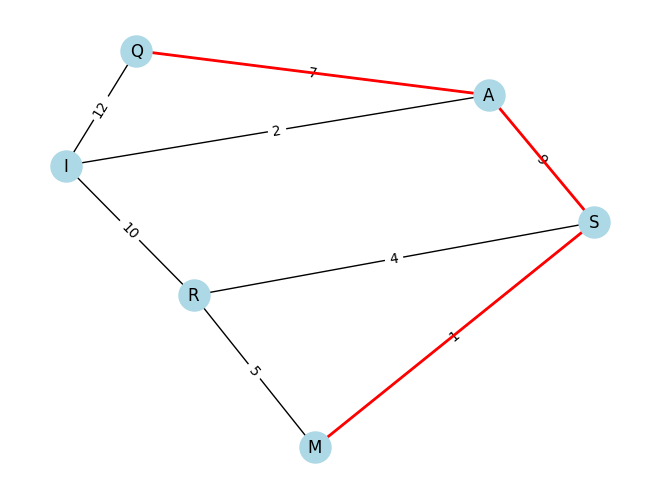

In [ ]:
#  a visualization of the graph with the shortest path highlighted
import matplotlib.pyplot as plt
import networkx as nx
G = nx.Graph()
for node, edges in graph.items():
    for neighbor, weight in edges:
        G.add_edge(node, neighbor, weight=weight)
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
# Highlight the shortest path
path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
plt.show()